In [1]:


import sys
import os

import pandas as pd
import numpy as np

import matplotlib.pyplot as plt
import seaborn as sns 

from sklearn.pipeline import Pipeline
from sklearn.linear_model import LogisticRegression
from sklearn.tree import DecisionTreeClassifier 
from sklearn.ensemble import RandomForestClassifier 
from sklearn.svm import SVC 
from sklearn.model_selection import train_test_split, GridSearchCV
from sklearn.metrics import classification_report, confusion_matrix , ConfusionMatrixDisplay , roc_auc_score 

# from xgboost import  XGBoost



sys.path.append(os.path.abspath('..'))

from src import loader ,get_preprocessor

df =  loader()
preprocessor = get_preprocessor()

In [12]:
def roc_auc_plot(fpr , tpr , roc_auc) : 
    plt.figure(figsize=(10, 6))
    plt.plot(fpr, tpr, color='darkorange', lw=2, label='ROC curve (area = %0.2f)' % roc_auc)
    plt.plot([0, 1], [0, 1], color='navy', lw=2, linestyle='--')
    plt.xlim([0.0, 1.0])
    plt.ylim([0.0, 1.05])
    plt.xlabel('False Positive Rate')
    plt.ylabel('True Positive Rate')
    plt.title('Receiver Operating Characteristic')
    plt.legend(loc="lower right")
    plt.show()

def confusion_matrix_plot(pred , y_test , ax) : 
    cm = confusion_matrix(y_test , pred)
    cm_percent = cm / cm.sum(axis=1, keepdims=True) * 100
    disp = ConfusionMatrixDisplay(confusion_matrix=cm_percent)
    if ax is not None:
        disp.plot(ax=ax, values_format='.2f')
    else:
        disp.plot(values_format='.2f')

    

In [21]:
models = {
    'logistic_regression' : Pipeline([
        ('preprocessor', preprocessor),
        ('classifier', LogisticRegression())
    ]),
    'decision_tree' : Pipeline([
        ('preprocessor', preprocessor),
        ('classifier', DecisionTreeClassifier())
    ]),
    'random_forest' : Pipeline([
        ('preprocessor', preprocessor),
        ('classifier', RandomForestClassifier())
    ]),
    'SVR' : Pipeline([
        ('preprocessor', preprocessor),
        ('classifier', SVC(probability=True))
    ]),
}

In [4]:
X = df.drop(columns=['Churn'])
Y = df['Churn'] 

X_train , X_test , y_train , y_test = train_test_split(X , Y , test_size=0.2 , random_state=42)

In [5]:
y_train

2142     No
1623     No
6074    Yes
1362    Yes
6754     No
       ... 
3772    Yes
5191     No
5226     No
5390    Yes
860      No
Name: Churn, Length: 5634, dtype: str

/home/fangyuan/Projects/telco-customer-segmentation-churn/.venv/lib/python3.14/site-packages/sklearn/svm/_base.py:236: FutureWarning: The `probability` parameter was deprecated in 1.9 and will be removed in version 1.11. Use `CalibratedClassifierCV(SVC(), ensemble=False)` instead of `SVC(probability=True)`
  warnings.warn(


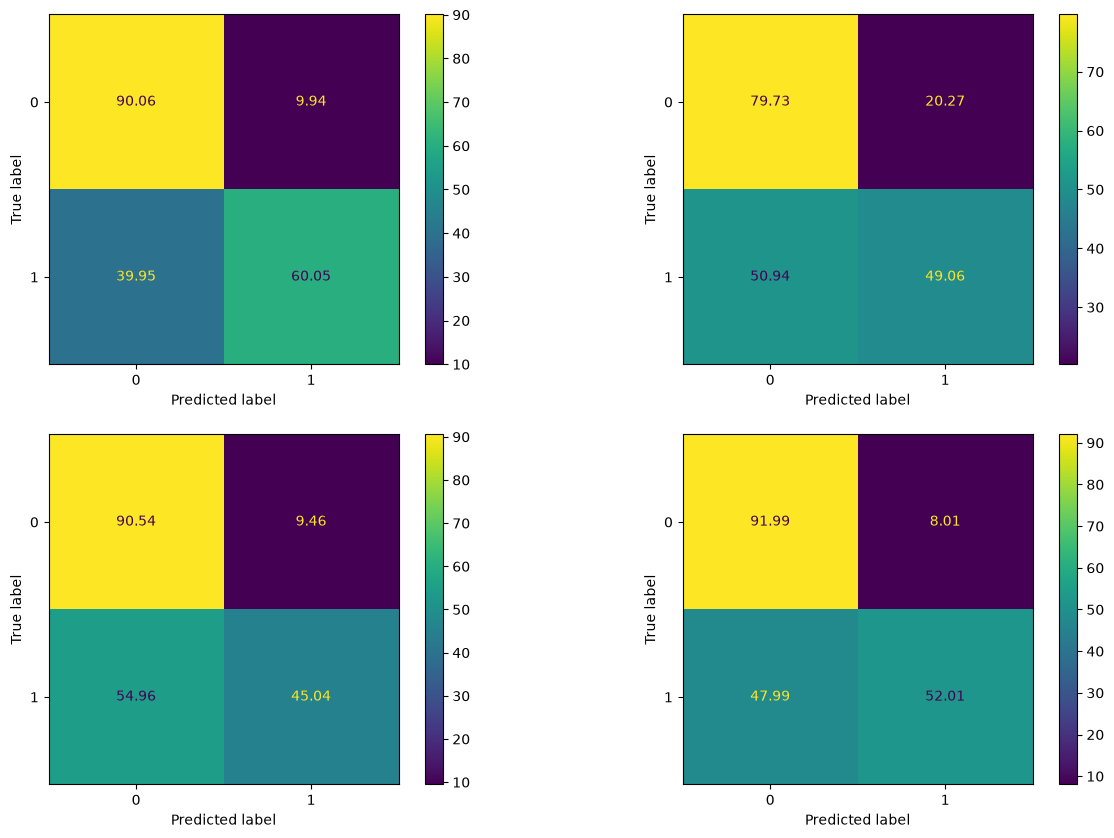

In [34]:
result = []
fig , axes = plt.subplots(2 , 2 , figsize=(15, 10))
for ax ,  (name , model) in zip(axes.flat , models.items()) : 
    model.fit(X_train , y_train)
    y_pred = model.predict(X_test)
    y_pred_proba = model.predict_proba(X_test)[:, 1]

    confusion_matrix_plot(y_pred , y_test , ax)

    scores = classification_report(y_test , y_pred, output_dict=True)

    # print(pd.DataFrame(scores))
    # break
    
    roc_auc = roc_auc_score(y_test , y_pred_proba)
    result.append({
        "model": name,
        "accuracy": scores["accuracy"],
        "roc_auc": roc_auc,
        "precision": scores["Yes"]["precision"],
        "recall": scores["Yes"]["recall"],
        "f1_score": scores["Yes"]["f1-score"]
    })


In [35]:
result_df = pd.DataFrame(
    result , 
    columns=['model' , 'accuracy' , 'roc_auc' , 'precision' , 'recall' , 'f1_score']
) 
result_df.sort_values(by='roc_auc' , ascending=False , ignore_index=True)

,model,accuracy,roc_auc,precision,recall,f1_score
0,logistic_regression,0.821150,0.862077,0.685015,0.600536,0.640000
1,random_forest,0.784954,0.832874,0.631579,0.450402,0.525822
2,SVR,0.814053,0.807676,0.700361,0.520107,0.596923
3,decision_tree,0.716111,0.644535,0.465649,0.490617,0.477807


In [ ]:



logistic_cv = GridSearchCV(
    models['logistic_regression'] , 
    cv=5 ,
)